Columns in dataset: ['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_day', 'route', 'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration', 'booking_complete']

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.98      0.92      8520
           1       0.53      0.14      0.22      1480

    accuracy                           0.85     10000
   macro avg       0.70      0.56      0.57     10000
weighted avg       0.82      0.85      0.82     10000

Accuracy: 0.8542

Cross-Validation Accuracy Scores: [0.8504 0.7514 0.7213 0.5008 0.754 ]
Mean CV Accuracy: 0.71558


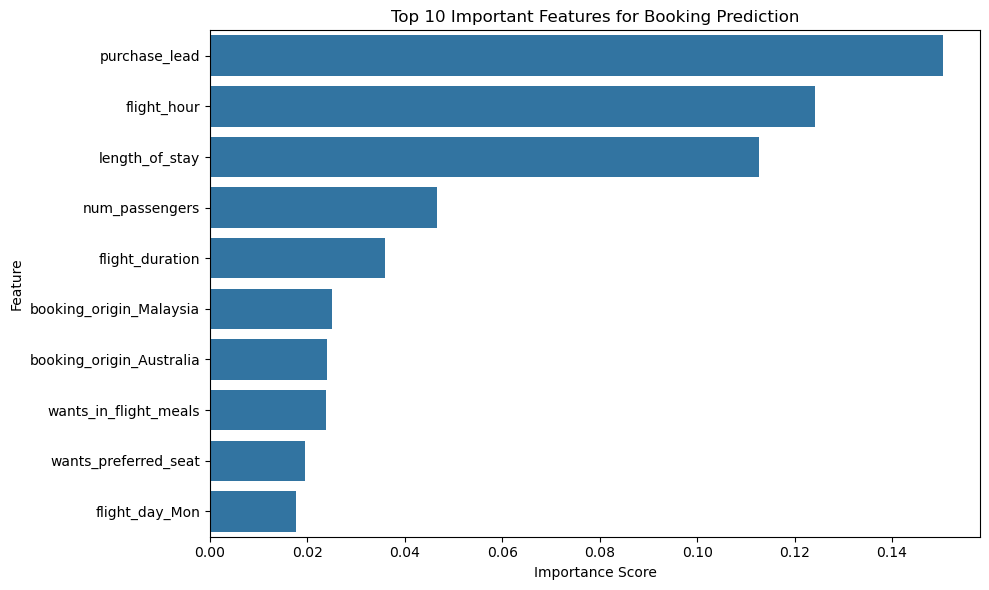

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib  inline
# Load your data (if not already done)
df = pd.read_csv("customer_booking.csv",encoding='ISO-8859-1')

# Print columns to verify
print("Columns in dataset:", df.columns.tolist())

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=[
    'sales_channel', 'trip_type', 'route', 'booking_origin', 'flight_day'
], drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop('booking_complete', axis=1)
y = df_encoded['booking_complete']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Cross-validation accuracy
cv_scores = cross_val_score(model, X, y, cv=5)
print("\nCross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# Feature Importance Plot
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features, y=top_features.index)
plt.title('Top 10 Important Features for Booking Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.savefig('feature_importance.png')

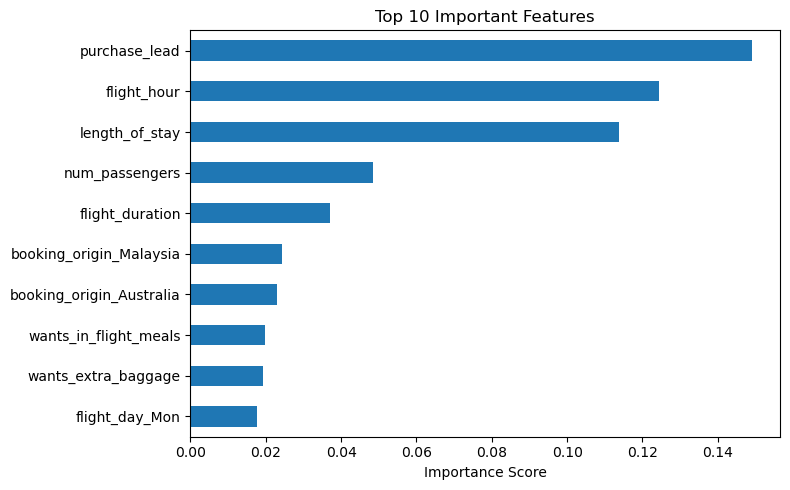

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# ✅ Step 1: Prepare data (use your existing df_encoded)
X = df_encoded.drop('booking_complete', axis=1)
y = df_encoded['booking_complete']

# ✅ Step 2: Split the data (fast train-test split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Step 3: Train a tiny random forest (only 10 trees for speed!)
model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

# ✅ Step 4: Get feature importances and plot top 10
importances = model.feature_importances_
feat_names = X.columns
feat_importance = pd.Series(importances, index=feat_names).sort_values(ascending=False)

# 🔍 Show top 10 features only
feat_importance[:10].plot(kind='barh', figsize=(8, 5), title='Top 10 Important Features')
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()  # Most important feature on top
plt.tight_layout()
plt.show()